<a href="https://colab.research.google.com/github/RAF-DI/RAF-DI/blob/main/Copia_de_Proyecto_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# instalar dependencias
!pip3 install -q otoole pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 935.4 kB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!apt-get install -y -qq glpk-utils

Selecting previously unselected package libsuitesparseconfig5:amd64.
(Reading database ... 121713 files and directories currently installed.)
Preparing to unpack .../libsuitesparseconfig5_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libsuitesparseconfig5:amd64 (1:5.10.1+dfsg-4build1) ...
Selecting previously unselected package libamd2:amd64.
Preparing to unpack .../libamd2_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libamd2:amd64 (1:5.10.1+dfsg-4build1) ...
Selecting previously unselected package libcolamd2:amd64.
Preparing to unpack .../libcolamd2_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libcolamd2:amd64 (1:5.10.1+dfsg-4build1) ...
Selecting previously unselected package libglpk40:amd64.
Preparing to unpack .../libglpk40_5.0-1_amd64.deb ...
Unpacking libglpk40:amd64 (5.0-1) ...
Selecting previously unselected package glpk-utils.
Preparing to unpack .../glpk-utils_5.0-1_amd64.deb ...
Unpacking glpk-utils (5.0-1) ...
Setting up libsuitesparseconfig5:amd64 (1:5.10.1+dfsg-4b

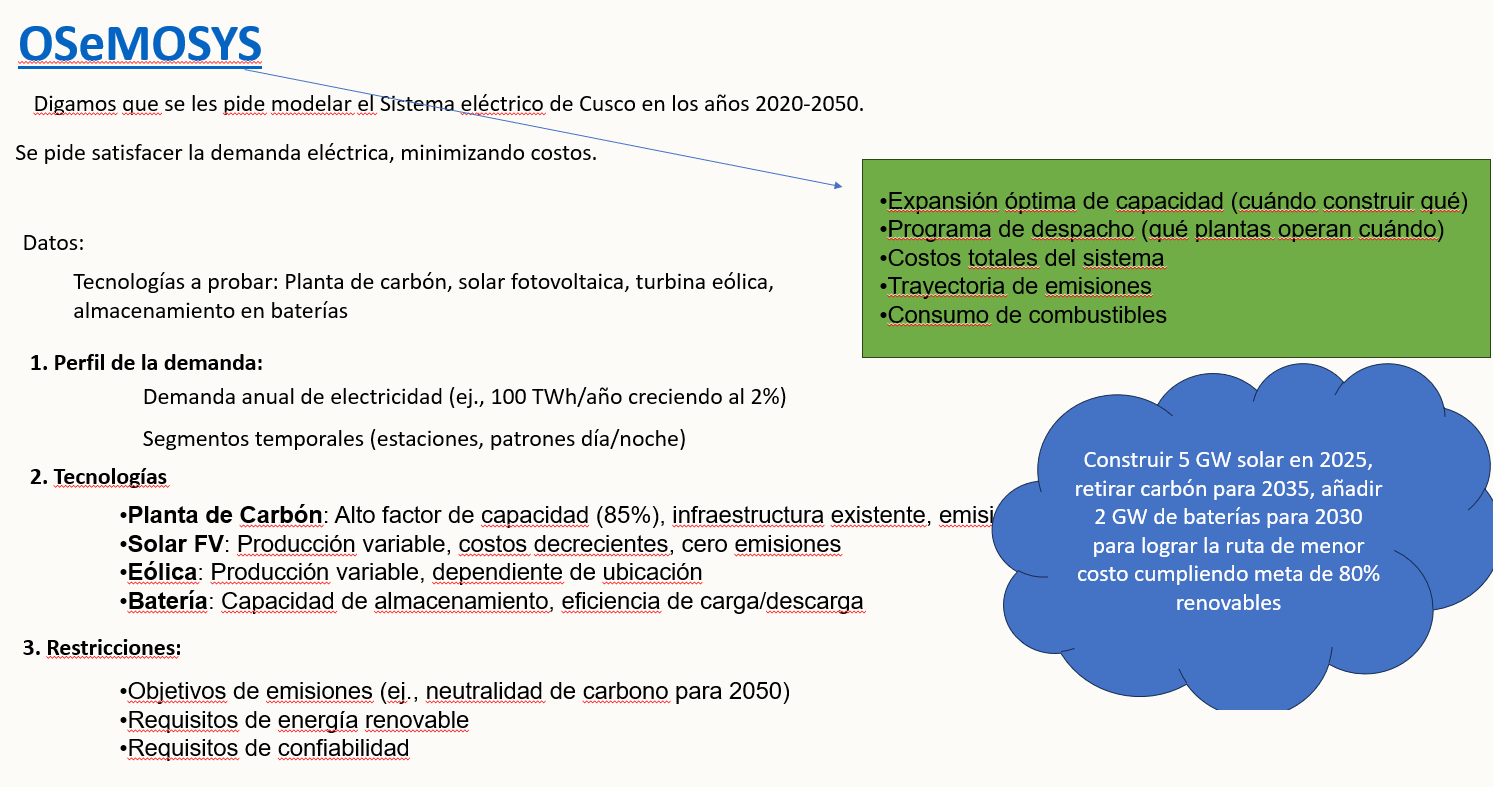

In [4]:
# cargar todas las librerias necesarias
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import json

Referencia de Global solar Atlas: https://globalsolaratlas.info/detail?c=-14.142327,-74.741089,8&m=site&a=-76.23523,-13.331494,-76.126465,-13.157589,-75.948486,-13.005623,-75.685914,-13.04919,-75.712281,-13.297292,-75.81775,-13.395608,-75.67273,-13.421249,-75.473877,-13.377855,-75.457397,-13.481517,-75.510132,-13.592118,-75.554078,-13.818331,-75.373902,-13.984649,-75.180543,-14.044324,-75.053101,-14.150847,-75.101441,-14.367999,-75.079468,-14.444591,-75.075074,-14.601947,-74.881714,-14.567933,-74.811402,-14.618951,-74.82898,-14.750693,-74.723511,-14.725201,-74.743286,-14.809934,-74.705933,-14.882355,-74.670777,-15.047881,-74.820191,-15.119993,-74.960816,-15.213278,-75.017945,-15.378545,-75.06189,-15.442074,-75.167358,-15.325517,-75.228882,-15.209038,-75.360718,-15.119993,-75.496949,-14.92481,-75.681519,-14.818658,-75.848511,-14.703955,-75.962769,-14.521156,-76.077027,-14.355231,-76.173707,-14.20196,-76.28357,-14.108243,-76.261597,-13.929223,-76.257203,-13.775666,-76.182496,-13.498155,-76.23523,-13.331494

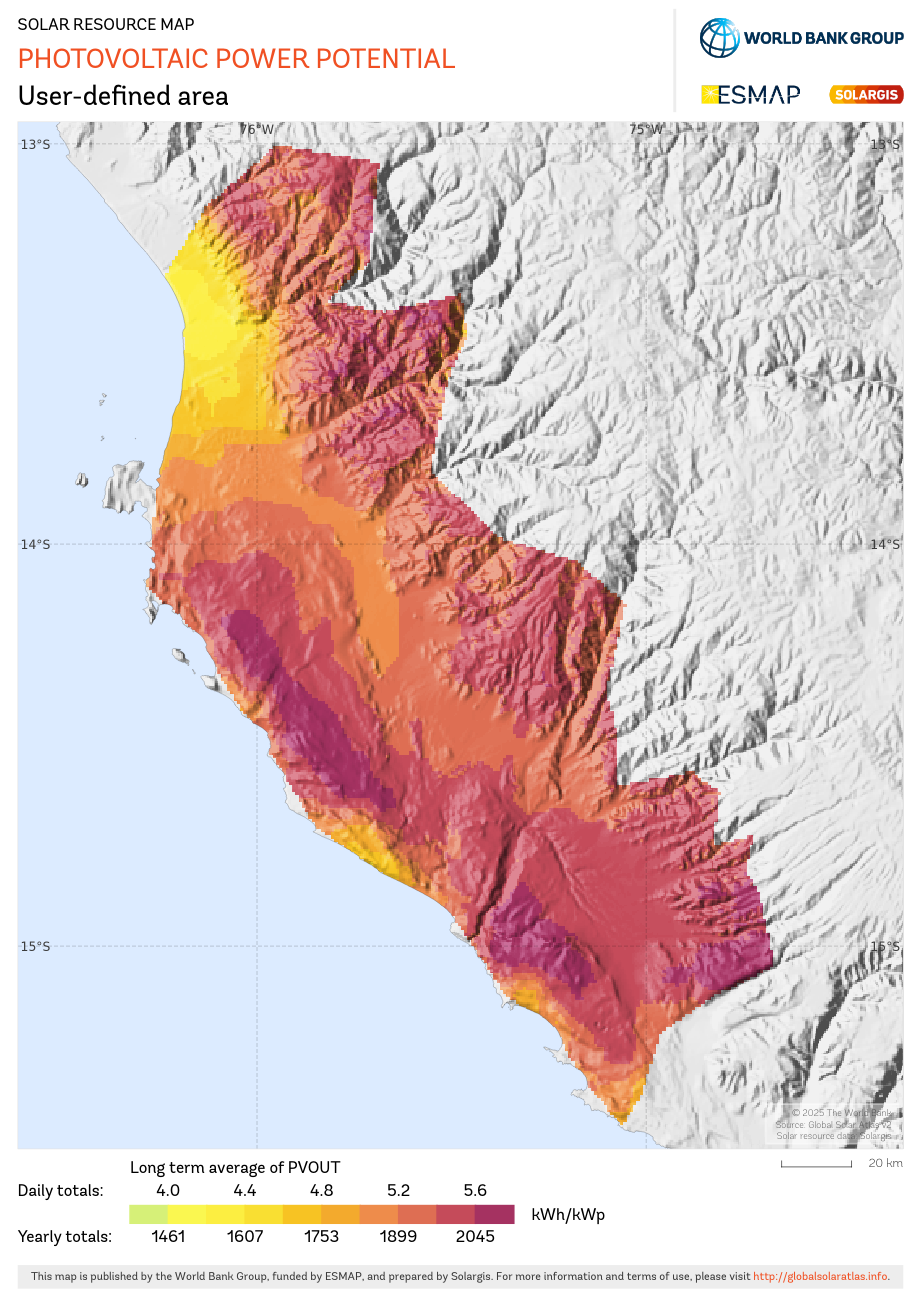

## Configuración del modelo OSeMOSYS

In [5]:
REGION = ['R1']  # ICA
TECHNOLOGY = ['NGCC', 'SOLAR']  # Tecnologías
FUEL = ['ELECTRICITY', 'GAS']  # Combustibles
EMISSION = ['CO2']  # Emisiones
MODE_OF_OPERATION = [1]  # Modo de operación simple
YEAR = list(range(2025, 2041))  # Horizonte 2025-2040
TIMESLICE = ['S1', 'S2']  # 2 estaciones: Verano (S1), Invierno (S2)
SEASON = ['SUMMER', 'WINTER']
DAYTYPE = ['ALLDAYS']
DAILYTIMEBRACKET = ['DAY', 'NIGHT']

# Generación del modelo

# 1. DEMANDA ANUAL

Demanda Anual consumo electrico Ica: https://revistaenergia.pe/ica-proyectos-eolicos-y-solares-en-desarrollo-suman-una-inversion-de-mas-de-us3500-millones/#:~:text=Actualmente%2C%20Ica%2C%20de%20acuerdo%20con%20las%20estad%C3%ADsticas,con%20importantes%20recursos%20energ%C3%A9ticos%20solares%20y%20e%C3%B3licos.

In [6]:
import pandas as pd

# DEMANDA ANUAL (AccumulatedAnnualDemand)

# Crear estructura de datos para OSeMOSYS
data = {}

# Demanda creciente de 0.004 TWh en 2025 a ~0.0084 TWh en 2040
demand_data = []
for year in YEAR:
    growth_factor = (1.05) ** (year - 2025)  # 5% crecimiento anual, cambiar si se necesita
    demand_data.append({
        'REGION': 'R1',
        'FUEL': 'ELECTRICITY',
        'YEAR': year,
        'VALUE': 0.004017 * growth_factor  # TWh
    })
data['AccumulatedAnnualDemand'] = pd.DataFrame(demand_data)

pd.DataFrame(demand_data)

,REGION,FUEL,YEAR,VALUE
0,R1,ELECTRICITY,2025,0.004017
1,R1,ELECTRICITY,2026,0.004218
2,R1,ELECTRICITY,2027,0.004429
3,R1,ELECTRICITY,2028,0.004650
4,R1,ELECTRICITY,2029,0.004883
5,R1,ELECTRICITY,2030,0.005127
6,R1,ELECTRICITY,2031,0.005383
7,R1,ELECTRICITY,2032,0.005652
8,R1,ELECTRICITY,2033,0.005935
9,R1,ELECTRICITY,2034,0.006232


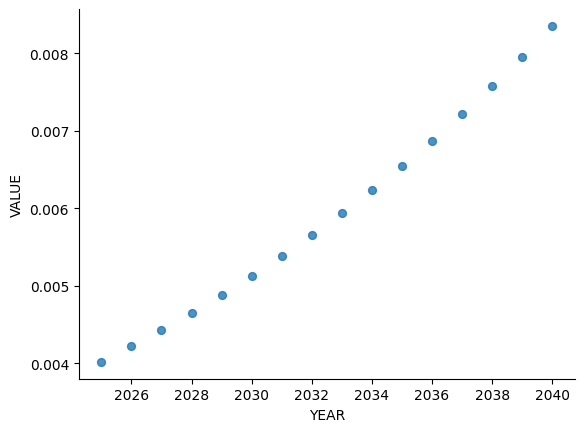

In [7]:
pd.DataFrame(demand_data).plot(kind='scatter', x='YEAR', y='VALUE', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

In [8]:
import matplotlib.pyplot as plt

# 2. COSTOS DE CAPITAL (CapitalCost) - $/MW


costo de capital promedio global a gran escala:

1) https://coldwellsolar.com/how-much-investment-do-you-need-for-a-solar-farm/#:~:text=How%20Much%20Does%20it%20Cost,SEIA's%20average%20national%20cost%20numbers.

2) https://gasturbineworld.com/capital-costs/?utm_source=chatgpt.com



In [9]:
capital_cost_data = []
for year in YEAR:
    # Solar y gas con costos decrecientes
    solar_cost = 1000000 * (0.95 ** (year - 2020))  # Reducción 5% anual
    # NGCC: tomo 1_050_000 USD/MW (1 050 $/kW) como valor base
    ngcc_cost = 1_050_000 * (0.995 ** (year - 2020))   # ejemplo: reducción 0.5% anual
    # wind_cost = 1500000 * (0.97 ** (year - 2020))   # Reducción 3% anual

    capital_cost_data.extend([
       # {'REGION': 'R1', 'TECHNOLOGY': 'COAL', 'YEAR': year, 'VALUE': 2000000},
       {'REGION': 'R1', 'TECHNOLOGY': 'SOLAR', 'YEAR': year, 'VALUE': solar_cost},
       {'REGION': 'R1', 'TECHNOLOGY': 'NGCC',  'YEAR': year, 'VALUE': ngcc_cost},
       # {'REGION': 'R1', 'TECHNOLOGY': 'WIND', 'YEAR': year, 'VALUE': wind_cost},
       # {'REGION': 'R1', 'TECHNOLOGY': 'BATTERY', 'YEAR': year, 'VALUE': 500000}
    ])
data['CapitalCost'] = pd.DataFrame(capital_cost_data)

#pd.DataFrame(capital_cost_data).head()
pd.DataFrame(capital_cost_data)

,REGION,TECHNOLOGY,YEAR,VALUE
0,R1,SOLAR,2025,7.737809e+05
1,R1,NGCC,2025,1.024011e+06
2,R1,SOLAR,2026,7.350919e+05
3,R1,NGCC,2026,1.018891e+06
4,R1,SOLAR,2027,6.983373e+05
5,R1,NGCC,2027,1.013797e+06
6,R1,SOLAR,2028,6.634204e+05
7,R1,NGCC,2028,1.008728e+06
8,R1,SOLAR,2029,6.302494e+05
9,R1,NGCC,2029,1.003684e+06


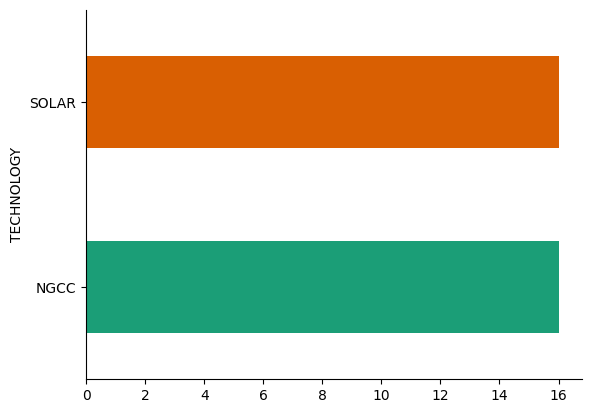

In [10]:
import seaborn as sns
capital_cost_df = pd.DataFrame(capital_cost_data)
capital_cost_df.groupby('TECHNOLOGY').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

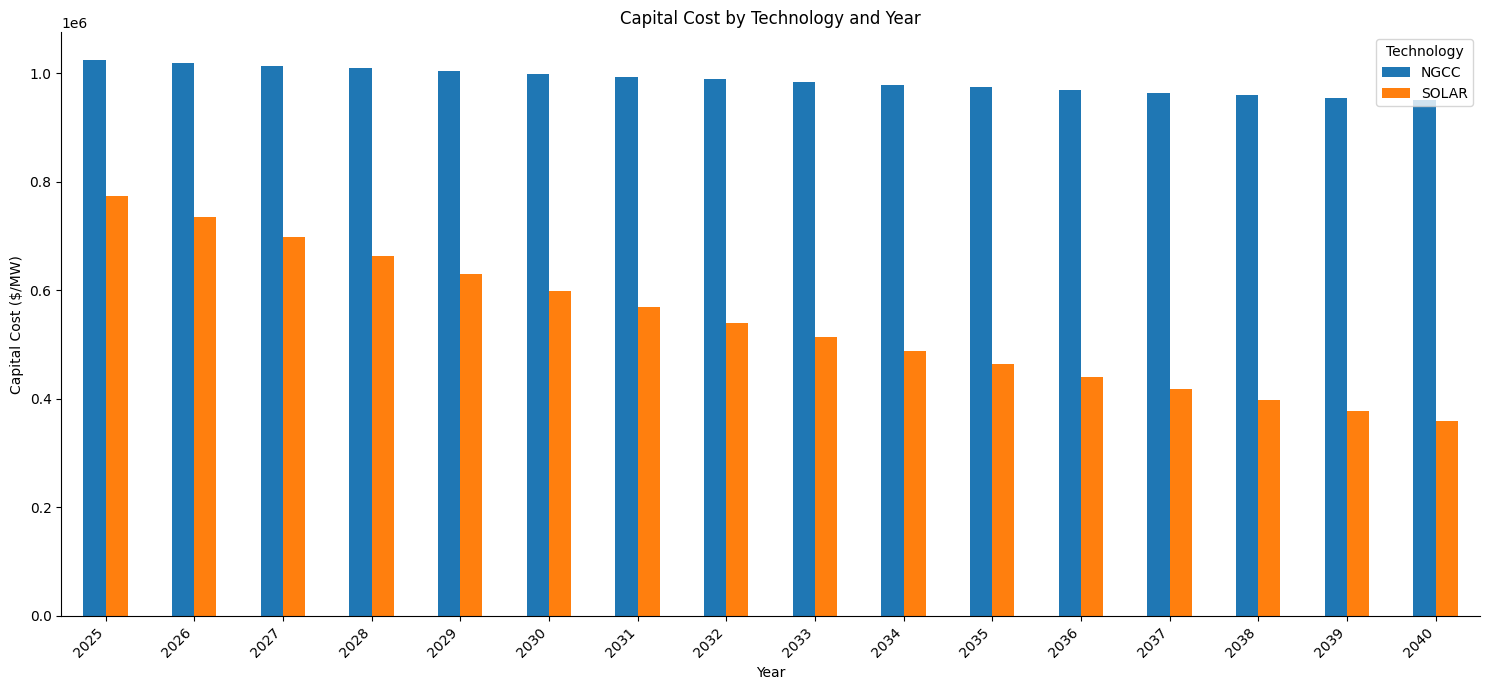

In [11]:
#b Daniel Cachi

capital_cost_df = pd.DataFrame(capital_cost_data)
pivot_capital_cost = capital_cost_df.pivot(index='YEAR', columns='TECHNOLOGY', values='VALUE')
pivot_capital_cost.plot(kind='bar', figsize=(15, 7))
plt.title('Capital Cost by Technology and Year')
plt.xlabel('Year')
plt.ylabel('Capital Cost ($/MW)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Technology')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# 3. COSTOS FIJOS (FixedCost) - $/MW/año


In [12]:
fixed_cost_data = []
for year in YEAR:
    fixed_cost_data.extend([
        #{'REGION': 'R1', 'TECHNOLOGY': 'COAL', 'YEAR': year, 'VALUE': 40000},
        # REFERENCIA: Muy usado en modelos (Solar PV utility scale)
        {'REGION': 'R1', 'TECHNOLOGY': 'SOLAR', 'YEAR': year, 'VALUE': 15000},

        #{'REGION': 'R1', 'TECHNOLOGY': 'WIND', 'YEAR': year, 'VALUE': 30000},

        # REFERENCIA: Valor estándar internacional (EIA/NREL)
        {'REGION': 'R1', 'TECHNOLOGY': 'NGCC', 'YEAR': year, 'VALUE': 30000}
    ])
data['FixedCost'] = pd.DataFrame(fixed_cost_data)

pd.DataFrame(fixed_cost_data)

,REGION,TECHNOLOGY,YEAR,VALUE
0,R1,SOLAR,2025,15000
1,R1,NGCC,2025,30000
2,R1,SOLAR,2026,15000
3,R1,NGCC,2026,30000
4,R1,SOLAR,2027,15000
5,R1,NGCC,2027,30000
6,R1,SOLAR,2028,15000
7,R1,NGCC,2028,30000
8,R1,SOLAR,2029,15000
9,R1,NGCC,2029,30000


# 4. COSTOS VARIABLES (VariableCost) - $/MWh

In [13]:
variable_cost_data = []
for year in YEAR:
    for timeslice in TIMESLICE:
        variable_cost_data.extend([
            #{'REGION': 'R1', 'TECHNOLOGY': 'COAL', 'MODE_OF_OPERATION': 1,
            # 'YEAR': year, 'VALUE': 30},  # Carbón: 30 $/MWh

            {'REGION': 'R1', 'TECHNOLOGY': 'SOLAR', 'MODE_OF_OPERATION': 1,
             'YEAR': year, 'VALUE': 0},   # Solar: 0 $/MWh

            #{'REGION': 'R1', 'TECHNOLOGY': 'WIND', 'MODE_OF_OPERATION': 1,
            #'YEAR': year, 'VALUE': 0},   # Eólica: 0 $/MWh
            #{'REGION': 'R1', 'TECHNOLOGY': 'BATTERY', 'MODE_OF_OPERATION': 1,
            #'YEAR': year, 'VALUE': 5}    # Batería: 5 $/MWh

            #https://publications.iadb.org/publications/english/document/Natural-Gas-Market-Rigidities-and-the-Promotion-of-NC-RER-in-Peru.pdf?utm_source=chatgpt.com
            #https://www.eia.gov/outlooks/aeo/assumptions/pdf/elec_cost_perf.pdf?utm_source=chatgpt.com
             {'REGION': 'R1', 'TECHNOLOGY': 'NGCC', 'MODE_OF_OPERATION': 1,
             'YEAR': year, 'VALUE': 32},   # NGCC realista para Perú
        ])
data['VariableCost'] = pd.DataFrame(variable_cost_data)

pd.DataFrame(variable_cost_data)

,REGION,TECHNOLOGY,MODE_OF_OPERATION,YEAR,VALUE
0,R1,SOLAR,1,2025,0
1,R1,NGCC,1,2025,32
2,R1,SOLAR,1,2025,0
3,R1,NGCC,1,2025,32
4,R1,SOLAR,1,2026,0
...,...,...,...,...,...
59,R1,NGCC,1,2039,32
60,R1,SOLAR,1,2040,0
61,R1,NGCC,1,2040,32
62,R1,SOLAR,1,2040,0


# 5. VIDA ÚTIL (OperationalLife) - años


In [14]:
operational_life_data = [
    #{'REGION': 'R1', 'TECHNOLOGY': 'COAL', 'VALUE': 40},
    {'REGION': 'R1', 'TECHNOLOGY': 'SOLAR', 'VALUE': 25},

    #https://www.eia.gov/outlooks/aeo/assumptions/
    {'REGION': 'R1', 'TECHNOLOGY': 'NGCC', 'VALUE': 30},

    #{'REGION': 'R1', 'TECHNOLOGY': 'WIND', 'VALUE': 25},
    #{'REGION': 'R1', 'TECHNOLOGY': 'BATTERY', 'VALUE': 15}
]
data['OperationalLife'] = pd.DataFrame(operational_life_data)

pd.DataFrame(operational_life_data)

,REGION,TECHNOLOGY,VALUE
0,R1,SOLAR,25
1,R1,NGCC,30


# 6. CAPACIDAD INSTALADA INICIAL (ResidualCapacity) - MW

In [15]:
residual_capacity_data = [
    #{'REGION': 'R1', 'TECHNOLOGY': 'COAL', 'YEAR': 2020, 'VALUE': 15000},  # 15 GW carbón existente

    #https://cvcenergia.com.pe/generacion/
    {'REGION': 'R1', 'TECHNOLOGY': 'SOLAR', 'YEAR': 2025, 'VALUE': 10},  # 0.01 GW solar
    #https://cvcenergia.com.pe/generacion/
    {'REGION': 'R1', 'TECHNOLOGY': 'NGCC', 'YEAR': 2025, 'VALUE': 10},  # 0.01 GW NGCC

    #{'REGION': 'R1', 'TECHNOLOGY': 'WIND', 'YEAR': 2020, 'VALUE': 3000},   # 3 GW eólica
    #{'REGION': 'R1', 'TECHNOLOGY': 'BATTERY', 'YEAR': 2020, 'VALUE': 500}  # 0.5 GW batería
]
data['ResidualCapacity'] = pd.DataFrame(residual_capacity_data)
pd.DataFrame(residual_capacity_data)

,REGION,TECHNOLOGY,YEAR,VALUE
0,R1,SOLAR,2025,10
1,R1,NGCC,2025,10


# 7. FACTOR DE CAPACIDAD (CapacityFactor)

In [16]:
# Varía por tecnología y temporada
capacity_factor_data = []
for year in YEAR:
    capacity_factor_data.extend([
        # Carbón: constante 85%
        #{'REGION': 'R1', 'TECHNOLOGY': 'COAL', 'TIMESLICE': 'S1', 'YEAR': year, 'VALUE': 0.85},
        #{'REGION': 'R1', 'TECHNOLOGY': 'COAL', 'TIMESLICE': 'S2', 'YEAR': year, 'VALUE': 0.85},

        # Solar: mejor en verano, solo día
        {'REGION': 'R1', 'TECHNOLOGY': 'SOLAR', 'TIMESLICE': 'S1', 'YEAR': year, 'VALUE': 0.35},
        {'REGION': 'R1', 'TECHNOLOGY': 'SOLAR', 'TIMESLICE': 'S2', 'YEAR': year, 'VALUE': 0.20},

        # gas: mejor en verano, solo día: REFERENCIA:https://www.coes.org.pe
        {'REGION': 'R1', 'TECHNOLOGY': 'NGCC', 'TIMESLICE': 'S1', 'YEAR': year, 'VALUE': 0.75},
        {'REGION': 'R1', 'TECHNOLOGY': 'NGCC', 'TIMESLICE': 'S2', 'YEAR': year, 'VALUE': 0.55},

        # Eólica: mejor en invierno
        #{'REGION': 'R1', 'TECHNOLOGY': 'WIND', 'TIMESLICE': 'S1', 'YEAR': year, 'VALUE': 0.30},
        #{'REGION': 'R1', 'TECHNOLOGY': 'WIND', 'TIMESLICE': 'S2', 'YEAR': year, 'VALUE': 0.45},

        # Batería: 90% eficiencia
        #{'REGION': 'R1', 'TECHNOLOGY': 'BATTERY', 'TIMESLICE': 'S1', 'YEAR': year, 'VALUE': 0.90},
        #{'REGION': 'R1', 'TECHNOLOGY': 'BATTERY', 'TIMESLICE': 'S2', 'YEAR': year, 'VALUE': 0.90}
    ])
data['CapacityFactor'] = pd.DataFrame(capacity_factor_data)

pd.DataFrame(capacity_factor_data)

,REGION,TECHNOLOGY,TIMESLICE,YEAR,VALUE
0,R1,SOLAR,S1,2025,0.35
1,R1,SOLAR,S2,2025,0.20
2,R1,NGCC,S1,2025,0.75
3,R1,NGCC,S2,2025,0.55
4,R1,SOLAR,S1,2026,0.35
...,...,...,...,...,...
59,R1,NGCC,S2,2039,0.55
60,R1,SOLAR,S1,2040,0.35
61,R1,SOLAR,S2,2040,0.20
62,R1,NGCC,S1,2040,0.75


# 8. OUTPUT ACTIVITY RATIO


In [17]:
# Producción de electricidad por tecnología
output_activity_data = []
for year in YEAR:
    output_activity_data.extend([
        #{'REGION': 'R1', 'TECHNOLOGY': 'COAL', 'FUEL': 'ELECTRICITY',
        # 'MODE_OF_OPERATION': 1, 'YEAR': year, 'VALUE': 1.0},
        {'REGION': 'R1', 'TECHNOLOGY': 'SOLAR', 'FUEL': 'ELECTRICITY',
         'MODE_OF_OPERATION': 1, 'YEAR': year, 'VALUE': 1.0},
        {'REGION': 'R1', 'TECHNOLOGY': 'NGCC', 'FUEL': 'GAS',
         'MODE_OF_OPERATION': 1, 'YEAR': year, 'VALUE': 1.0},
        #{'REGION': 'R1', 'TECHNOLOGY': 'WIND', 'FUEL': 'ELECTRICITY',
        # 'MODE_OF_OPERATION': 1, 'YEAR': year, 'VALUE': 1.0},
        #{'REGION': 'R1', 'TECHNOLOGY': 'BATTERY', 'FUEL': 'ELECTRICITY',
        # 'MODE_OF_OPERATION': 1, 'YEAR': year, 'VALUE': 0.85}  # 85% eficiencia descarga
    ])
data['OutputActivityRatio'] = pd.DataFrame(output_activity_data)
pd.DataFrame(output_activity_data)

,REGION,TECHNOLOGY,FUEL,MODE_OF_OPERATION,YEAR,VALUE
0,R1,SOLAR,ELECTRICITY,1,2025,1.0
1,R1,NGCC,GAS,1,2025,1.0
2,R1,SOLAR,ELECTRICITY,1,2026,1.0
3,R1,NGCC,GAS,1,2026,1.0
4,R1,SOLAR,ELECTRICITY,1,2027,1.0
5,R1,NGCC,GAS,1,2027,1.0
6,R1,SOLAR,ELECTRICITY,1,2028,1.0
7,R1,NGCC,GAS,1,2028,1.0
8,R1,SOLAR,ELECTRICITY,1,2029,1.0
9,R1,NGCC,GAS,1,2029,1.0


# 9. INPUT ACTIVITY RATIO


In [18]:
# Consumo de combustible
input_activity_data = []
for year in YEAR:
    input_activity_data.extend([
        # Carbón consume combustible fósil (eficiencia 38%)
        #{'REGION': 'R1', 'TECHNOLOGY': 'COAL', 'FUEL': 'COAL_FUEL',
        # 'MODE_OF_OPERATION': 1, 'YEAR': year, 'VALUE': 2.63},  # 1/0.38

        # NGCS consume GAS (EFICIENCIA 60%)
        {'REGION': 'R1', 'TECHNOLOGY': 'NGCC', 'FUEL': 'GAS',
         'MODE_OF_OPERATION': 1, 'YEAR': year, 'VALUE': 1.66},  # 1/0.6
        # Batería consume electricidad para cargar
        {'REGION': 'R1', 'TECHNOLOGY': 'BATTERY', 'FUEL': 'ELECTRICITY',
         'MODE_OF_OPERATION': 1, 'YEAR': year, 'VALUE': 1.18}  # 1/0.85
    ])
data['InputActivityRatio'] = pd.DataFrame(input_activity_data)
pd.DataFrame(input_activity_data)

,REGION,TECHNOLOGY,FUEL,MODE_OF_OPERATION,YEAR,VALUE
0,R1,NGCC,GAS,1,2025,1.66
1,R1,BATTERY,ELECTRICITY,1,2025,1.18
2,R1,NGCC,GAS,1,2026,1.66
3,R1,BATTERY,ELECTRICITY,1,2026,1.18
4,R1,NGCC,GAS,1,2027,1.66
5,R1,BATTERY,ELECTRICITY,1,2027,1.18
6,R1,NGCC,GAS,1,2028,1.66
7,R1,BATTERY,ELECTRICITY,1,2028,1.18
8,R1,NGCC,GAS,1,2029,1.66
9,R1,BATTERY,ELECTRICITY,1,2029,1.18


# 10. EMISIONES (EmissionActivityRatio) - tCO2/MWh


In [19]:
emission_data = []
for year in YEAR:
    emission_data.append({
        'REGION': 'R1',
        'TECHNOLOGY': 'NGCC',
        'EMISSION': 'CO2',
        'MODE_OF_OPERATION': 1,
        'YEAR': year,
        'VALUE': 0.34  # 0.34 tCO2/MWh
    })
data['EmissionActivityRatio'] = pd.DataFrame(emission_data)
pd.DataFrame(emission_data)

,REGION,TECHNOLOGY,EMISSION,MODE_OF_OPERATION,YEAR,VALUE
0,R1,NGCC,CO2,1,2025,0.34
1,R1,NGCC,CO2,1,2026,0.34
2,R1,NGCC,CO2,1,2027,0.34
3,R1,NGCC,CO2,1,2028,0.34
4,R1,NGCC,CO2,1,2029,0.34
5,R1,NGCC,CO2,1,2030,0.34
6,R1,NGCC,CO2,1,2031,0.34
7,R1,NGCC,CO2,1,2032,0.34
8,R1,NGCC,CO2,1,2033,0.34
9,R1,NGCC,CO2,1,2034,0.34


# 11. LÍMITE DE EMISIONES (AnnualEmissionLimit)


In [20]:
# Reducción gradual: de 100 MtCO2 en 2025 a casi 6% en 2040
emission_limit_data = []
for year in YEAR:
    reduction_factor = max(0, 1 - ((year - 2020) / 15) * 0.7)  # 70% reducción en 15 años
    emission_limit_data.append({
        'REGION': 'R1',
        'EMISSION': 'CO2',
        'YEAR': year,
        'VALUE': 100.0 * reduction_factor  # MtCO2
    })
data['AnnualEmissionLimit'] = pd.DataFrame(emission_limit_data)
pd.DataFrame(emission_limit_data)

,REGION,EMISSION,YEAR,VALUE
0,R1,CO2,2025,76.666667
1,R1,CO2,2026,72.000000
2,R1,CO2,2027,67.333333
3,R1,CO2,2028,62.666667
4,R1,CO2,2029,58.000000
5,R1,CO2,2030,53.333333
6,R1,CO2,2031,48.666667
7,R1,CO2,2032,44.000000
8,R1,CO2,2033,39.333333
9,R1,CO2,2034,34.666667


# 12. TASA DE DESCUENTO (DiscountRate)

In [21]:
data['DiscountRate'] = pd.DataFrame([{'REGION': 'R1', 'VALUE': 0.05}])  # 5%

# 13. YEAR SPLIT (distribución temporal)

In [22]:
data['YearSplit'] = pd.DataFrame([
    {'TIMESLICE': 'S1', 'VALUE': 0.5},  # 50% verano
    {'TIMESLICE': 'S2', 'VALUE': 0.5}   # 50% invierno
])

# RESUMEN DEL MODELO PARA OSE



In [23]:
print(f"   - Región: {REGION}")
print(f"   - Tecnologías: {TECHNOLOGY}")
print(f"   - Período: {min(YEAR)}-{max(YEAR)}")
print(f"   - Segmentos temporales: {len(TIMESLICE)}")
print(f"   - Tablas de datos: {len(data)}\n")

for table_name, df in data.items():
    print(f"\n{'='*50}")
    print(f"📊 TABLA: {table_name}")
    print(f"{'='*50}")
    print(f"Registros: {len(df)} | Columnas: {list(df.columns)}")

    # Mostrar tabla completa
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', None):
        print(df.to_string(index=False))
    print("\n" + "-"*50)

   - Región: ['R1']
   - Tecnologías: ['NGCC', 'SOLAR']
   - Período: 2025-2040
   - Segmentos temporales: 2
   - Tablas de datos: 13


📊 TABLA: AccumulatedAnnualDemand
Registros: 16 | Columnas: ['REGION', 'FUEL', 'YEAR', 'VALUE']
REGION        FUEL  YEAR    VALUE
    R1 ELECTRICITY  2025 0.004017
    R1 ELECTRICITY  2026 0.004218
    R1 ELECTRICITY  2027 0.004429
    R1 ELECTRICITY  2028 0.004650
    R1 ELECTRICITY  2029 0.004883
    R1 ELECTRICITY  2030 0.005127
    R1 ELECTRICITY  2031 0.005383
    R1 ELECTRICITY  2032 0.005652
    R1 ELECTRICITY  2033 0.005935
    R1 ELECTRICITY  2034 0.006232
    R1 ELECTRICITY  2035 0.006543
    R1 ELECTRICITY  2036 0.006870
    R1 ELECTRICITY  2037 0.007214
    R1 ELECTRICITY  2038 0.007575
    R1 ELECTRICITY  2039 0.007953
    R1 ELECTRICITY  2040 0.008351

--------------------------------------------------

📊 TABLA: CapitalCost
Registros: 32 | Columnas: ['REGION', 'TECHNOLOGY', 'YEAR', 'VALUE']
REGION TECHNOLOGY  YEAR        VALUE
    R1      

In [24]:
# GUARDAR DATOS EN FORMATO CSV
# Crear directorio para datos
!mkdir -p osemosys_data

# Guardar cada tabla en CSV
for table_name, df in data.items():
    filename = f"osemosys_data/{table_name}.csv"
    df.to_csv(filename, index=False)
    print(f"   ✓ {table_name}.csv ({len(df)} filas)")

   ✓ AccumulatedAnnualDemand.csv (16 filas)
   ✓ CapitalCost.csv (32 filas)
   ✓ FixedCost.csv (32 filas)
   ✓ VariableCost.csv (64 filas)
   ✓ OperationalLife.csv (2 filas)
   ✓ ResidualCapacity.csv (2 filas)
   ✓ CapacityFactor.csv (64 filas)
   ✓ OutputActivityRatio.csv (32 filas)
   ✓ InputActivityRatio.csv (32 filas)
   ✓ EmissionActivityRatio.csv (16 filas)
   ✓ AnnualEmissionLimit.csv (16 filas)
   ✓ DiscountRate.csv (1 filas)
   ✓ YearSplit.csv (2 filas)


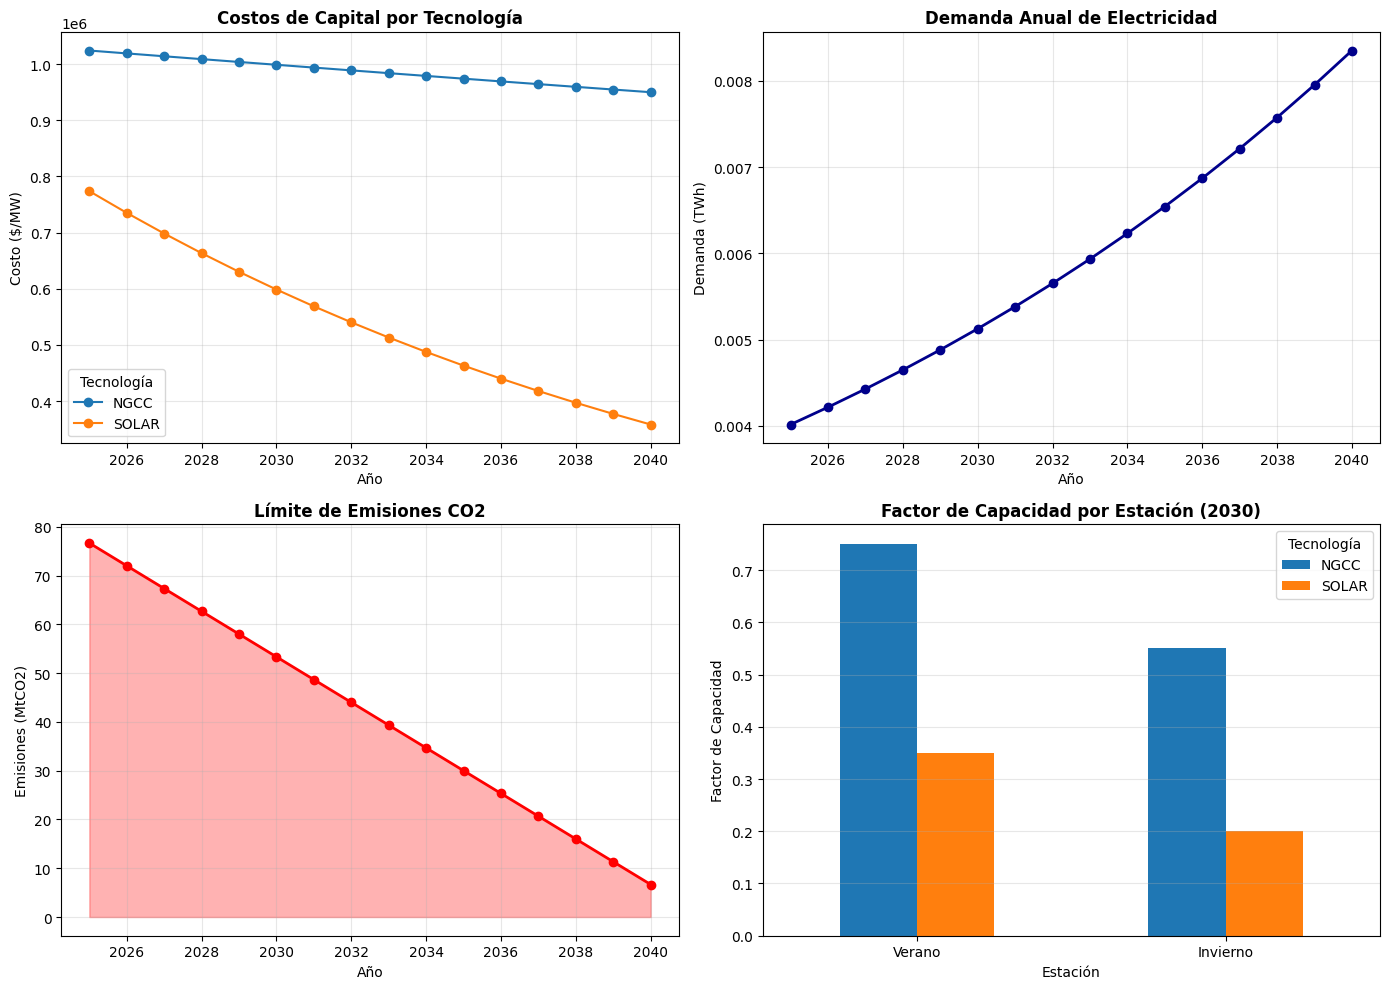

In [25]:
# Gráfico 1: Costos de capital a lo largo del tiempo
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Costos de capital
capital_pivot = data['CapitalCost'].pivot(index='YEAR', columns='TECHNOLOGY', values='VALUE')
capital_pivot.plot(ax=axes[0, 0], marker='o')
axes[0, 0].set_title('Costos de Capital por Tecnología', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Costo ($/MW)')
axes[0, 0].set_xlabel('Año')
axes[0, 0].legend(title='Tecnología')
axes[0, 0].grid(True, alpha=0.3)


# Demanda
demand_df = data['AccumulatedAnnualDemand']
axes[0, 1].plot(demand_df['YEAR'], demand_df['VALUE'], marker='o', linewidth=2, color='darkblue')
axes[0, 1].set_title('Demanda Anual de Electricidad', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Demanda (TWh)')
axes[0, 1].set_xlabel('Año')
axes[0, 1].grid(True, alpha=0.3)

# Límite de emisiones
emission_df = data['AnnualEmissionLimit']
axes[1, 0].plot(emission_df['YEAR'], emission_df['VALUE'], marker='o', linewidth=2, color='red')
axes[1, 0].set_title('Límite de Emisiones CO2', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Emisiones (MtCO2)')
axes[1, 0].set_xlabel('Año')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].fill_between(emission_df['YEAR'], emission_df['VALUE'], alpha=0.3, color='red')

# Factor de capacidad por estación
cf_2030 = data['CapacityFactor'][data['CapacityFactor']['YEAR'] == 2030]
cf_pivot = cf_2030.pivot(index='TIMESLICE', columns='TECHNOLOGY', values='VALUE')
cf_pivot.plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('Factor de Capacidad por Estación (2030)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Factor de Capacidad')
axes[1, 1].set_xlabel('Estación')
axes[1, 1].set_xticklabels(['Verano', 'Invierno'], rotation=0)
axes[1, 1].legend(title='Tecnología')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('modelo_parametros.png', dpi=300, bbox_inches='tight')
plt.show()

CREANDO MODELO OSEMOSYS

In [26]:
!pip install -q otoole pandas numpy matplotlib

In [27]:
!apt-get install -y -qq glpk-utils

In [28]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import json

# 1. Crear archivo de configuración completo para OSeMOSYS

In [29]:
config_content = """
# Configuración OSeMOSYS - Sistema Eléctrico Simple
# Generado automáticamente

# SETS (Conjuntos)
set REGION := R1;
set TECHNOLOGY := SOLAR NGCC;
set FUEL := ELECTRICITY GAS;
set EMISSION := CO2;
set MODE_OF_OPERATION := 1;
set TIMESLICE := S1 S2;
set SEASON := SUMMER WINTER;
set DAYTYPE := ALLDAYS;
set DAILYTIMEBRACKET := DAY NIGHT;
"""

In [30]:
# Definir los años de interés
config_content += "set YEAR := " + " ".join(map(str, YEAR)) + ";\n\n"

In [31]:
YEAR

[2025,
 2026,
 2027,
 2028,
 2029,
 2030,
 2031,
 2032,
 2033,
 2034,
 2035,
 2036,
 2037,
 2038,
 2039,
 2040]

In [32]:
import os

# Ensure the directory exists before writing the file
os.makedirs('osemosys_data', exist_ok=True)

# Guardar configuración
with open('osemosys_data/config.txt', 'w') as f:
    f.write(config_content)

# 2. Usar otoole para convertir dat
Crear archivo de datos en formato GNU MathProg (.txt)
Nota: Este es un proceso simplificado. Un modelo real necesita más parámetros.

LCOE (Levelized Cost of Energy), es el costo promedio de producir electricidad a lo largo de la vida útil de una planta.

Sirve como indicador del costo real de generación, combinando inversión inicial, operación, combustible, mantenimiento y el rendimiento energético del sistema.

In [33]:
# Costo Nivelado de Energía (LCOE)

discount_rate = 0.05
for tech in TECHNOLOGY:
    # Obtener datos de la tecnología
    capital = data['CapitalCost'][
        (data['CapitalCost']['TECHNOLOGY'] == tech) &
        (data['CapitalCost']['YEAR'] == 2040)
    ]['VALUE'].values[0]

    fixed = data['FixedCost'][
        (data['FixedCost']['TECHNOLOGY'] == tech) &
        (data['FixedCost']['YEAR'] == 2040)
    ]['VALUE'].values[0]

    variable = data['VariableCost'][
        (data['VariableCost']['TECHNOLOGY'] == tech) &
        (data['VariableCost']['YEAR'] == 2040)
    ]['VALUE'].values[0]

    lifetime = data['OperationalLife'][
        data['OperationalLife']['TECHNOLOGY'] == tech
    ]['VALUE'].values[0]

    # Factor de capacidad promedio
    cf_avg = data['CapacityFactor'][
        (data['CapacityFactor']['TECHNOLOGY'] == tech) &
        (data['CapacityFactor']['YEAR'] == 2040)
    ]['VALUE'].mean()

    # LCOE = (Capital * CRF + Fixed) / (8760 * CF) + Variable
    crf = (discount_rate * (1 + discount_rate)**lifetime) / ((1 + discount_rate)**lifetime - 1)
    lcoe = (capital * crf + fixed) / (8760 * cf_avg) + variable

    print(f"   {tech:12s}: ${lcoe:8.2f} /MWh  (FC: {cf_avg*100:5.1f}%)")

   NGCC        : $   48.12 /MWh  (FC:  65.0%)
   SOLAR       : $   16.79 /MWh  (FC:  27.5%)


In [34]:
print("Capacidad Requerida vs Instalada\n")

for year in [2025, 2030, 2035, 2040]:
    demand = data['AccumulatedAnnualDemand'][
        data['AccumulatedAnnualDemand']['YEAR'] == year
    ]['VALUE'].values[0]

    # Capacidad necesaria (asumiendo factor de carga 50%)
    required_capacity = (demand * 1000) / (8760 * 0.5)  # MW

    print(f"   Año {year}: Demanda = {demand:6.6f} TWh  →  Capacidad requerida ≈ {required_capacity:,.5f} MW")

Capacidad Requerida vs Instalada

   Año 2025: Demanda = 0.004017 TWh  →  Capacidad requerida ≈ 0.00092 MW
   Año 2030: Demanda = 0.005127 TWh  →  Capacidad requerida ≈ 0.00117 MW
   Año 2035: Demanda = 0.006543 TWh  →  Capacidad requerida ≈ 0.00149 MW
   Año 2040: Demanda = 0.008351 TWh  →  Capacidad requerida ≈ 0.00191 MW


In [35]:
print("Restricciones de Emisiones CO2\n")

for year in [2025, 2030, 2035, 2040]:
    limit = data['AnnualEmissionLimit'][
        data['AnnualEmissionLimit']['YEAR'] == year
    ]['VALUE'].values[0]

    reduction = ((100 - limit) / 100) * 100
    print(f"   Año {year}: Límite = {limit:6.1f} MtCO2  (Reducción: {reduction:5.1f}%)")

Restricciones de Emisiones CO2

   Año 2025: Límite =   76.7 MtCO2  (Reducción:  23.3%)
   Año 2030: Límite =   53.3 MtCO2  (Reducción:  46.7%)
   Año 2035: Límite =   30.0 MtCO2  (Reducción:  70.0%)
   Año 2040: Límite =    6.7 MtCO2  (Reducción:  93.3%)


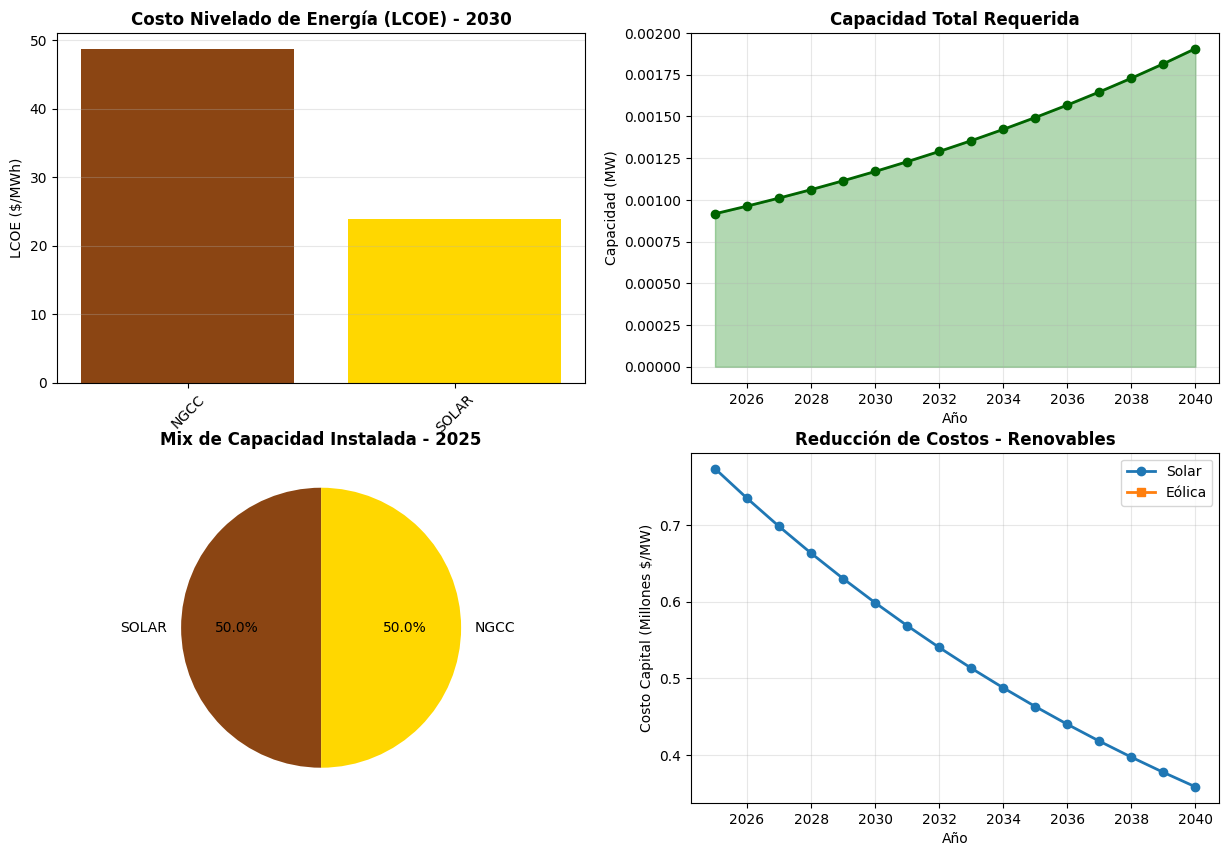

In [36]:
# Crear gráficos de análisis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Gráfico 1: LCOE Comparativo (2030)
lcoe_data = []
for tech in TECHNOLOGY:
    capital = data['CapitalCost'][
        (data['CapitalCost']['TECHNOLOGY'] == tech) &
        (data['CapitalCost']['YEAR'] == 2030)
    ]['VALUE'].values[0]

    fixed = data['FixedCost'][
        (data['FixedCost']['TECHNOLOGY'] == tech) &
        (data['FixedCost']['YEAR'] == 2030)
    ]['VALUE'].values[0]

    variable = data['VariableCost'][
        (data['VariableCost']['TECHNOLOGY'] == tech) &
        (data['VariableCost']['YEAR'] == 2030)
    ]['VALUE'].values[0]

    lifetime = data['OperationalLife'][
        data['OperationalLife']['TECHNOLOGY'] == tech
    ]['VALUE'].values[0]

    cf_avg = data['CapacityFactor'][
        (data['CapacityFactor']['TECHNOLOGY'] == tech) &
        (data['CapacityFactor']['YEAR'] == 2030)
    ]['VALUE'].mean()

    crf = (0.05 * (1 + 0.05)**lifetime) / ((1 + 0.05)**lifetime - 1)
    lcoe = (capital * crf + fixed) / (8760 * cf_avg) + variable

    lcoe_data.append({'Technology': tech, 'LCOE': lcoe})


capacity_req = []
for year in YEAR:
    demand = data['AccumulatedAnnualDemand'][
        data['AccumulatedAnnualDemand']['YEAR'] == year
    ]['VALUE'].values[0]
    required = (demand * 1000) / (8760 * 0.5)
    capacity_req.append({'Year': year, 'Capacity': required})

cap_df = pd.DataFrame(capacity_req)
axes[0, 1].plot(cap_df['Year'], cap_df['Capacity'], marker='o', linewidth=2, color='darkgreen')
axes[0, 1].fill_between(cap_df['Year'], cap_df['Capacity'], alpha=0.3, color='green')
axes[0, 1].set_title('Capacidad Total Requerida', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Capacidad (MW)')
axes[0, 1].set_xlabel('Año')
axes[0, 1].grid(True, alpha=0.3)

lcoe_df = pd.DataFrame(lcoe_data)
colors = ['#8B4513', '#FFD700', '#87CEEB', '#32CD32']
axes[0, 0].bar(lcoe_df['Technology'], lcoe_df['LCOE'], color=colors)
axes[0, 0].set_title('Costo Nivelado de Energía (LCOE) - 2030', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('LCOE ($/MWh)')
axes[0, 0].grid(True, alpha=0.3, axis='y')
axes[0, 0].tick_params(axis='x', rotation=45)

initial_capacity = data['ResidualCapacity'][data['ResidualCapacity']['YEAR'] == 2025]
axes[1, 0].pie(initial_capacity['VALUE'], labels=initial_capacity['TECHNOLOGY'],
               autopct='%1.1f%%', colors=colors, startangle=90)
axes[1, 0].set_title('Mix de Capacidad Instalada - 2025', fontsize=12, fontweight='bold')



capital_solar = data['CapitalCost'][data['CapitalCost']['TECHNOLOGY'] == 'SOLAR']
capital_wind = data['CapitalCost'][data['CapitalCost']['TECHNOLOGY'] == 'WIND']

axes[1, 1].plot(capital_solar['YEAR'], capital_solar['VALUE']/1e6,
                marker='o', label='Solar', linewidth=2)
axes[1, 1].plot(capital_wind['YEAR'], capital_wind['VALUE']/1e6,
                marker='s', label='Eólica', linewidth=2)
axes[1, 1].set_title('Reducción de Costos - Renovables', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Costo Capital (Millones $/MW)')
axes[1, 1].set_xlabel('Año')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)